In [1]:
import numpy as np 
import pandas as pd
import statsmodels.api as sm

from ufc_betting.Models.LogisticRegression.train_test_builder import TrainTestBuilder
from ufc_betting.Models.LogisticRegression.statistical_functions import run_logit_model
from ufc_betting.Models.LogisticRegression.visual_functions import plot_model_metrics, expected_calibration_error
from ufc_betting.Models.LogisticRegression.utils import save_results
from ufc_betting.config import config
import joblib


In [2]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-07.csv'
df_model = pd.read_csv(fp)
winner_col = 'winner'
date_col = 'date'

In [3]:
def workflow(
    feats, 
    odds_type,
    model_path, 
    model_se_path,
    scalar_path,
    encoder_path,
    save_model,
    alpha
):
    builder = TrainTestBuilder(
        df=df_model,
        feats=feats,
        target_col=winner_col,
        date_col=date_col,
        odds_type=odds_type,
        year=2010, 
        month=2, 
        day=26, 
    )
    pkt = builder.prepare_train_test(
        train_size=0.85, scale=True
    )
    X_train = pkt['X_train']
    y_train = pkt['y_train']
    print(y_train.value_counts())

    X_test = pkt['X_test']
    y_test = pkt['y_test']

    results = run_logit_model(
        X_train, 
        y_train,
        X_test, 
        y_test,
        cov_type="HC3",
        reg=True,
        alpha=alpha,
    )

    df_train = pkt['train_df']
    df_test = pkt['test_df']
    df_train['proba_se'] = results['proba_train_se']
    df_test['proba_se'] = results['proba_test_se']

    if save_model:
        results['model'].save(model_path)
        results['model_se'].save(model_se_path)
        joblib.dump(pkt['scaler'], scalar_path)
        joblib.dump(pkt['encoder'], encoder_path)

    png_path = fr'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\train_{odds_type}_model_metrics.png'
    plot_model_metrics(
        y_train, 
        results["train_pred_class"], 
        results["train_pred_proba"], 
        suptitle=f'Train Results for {odds_type} Odds',
        path=png_path
    )
    
    png_path = fr'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\test_{odds_type}_model_metrics.png'
    plot_model_metrics(
        y_test, 
        results['test_pred_class'], 
        results["test_pred_proba"], 
        suptitle=f'Test Results for {odds_type} Odds', path=png_path
    )

    df_results_train = save_results(
        df_train, 
        results['train_pred_proba'], 
        fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_{odds_type}.csv'
    )
    df_results_test = save_results(
        df_test, 
        results['test_pred_proba'], 
        fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_{odds_type}.csv'
    )

    return df_results_train, df_results_test


Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 51)
winner
1.0    2095
0.0    1593
Name: count, dtype: int64
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6256349927715447
            Iterations: 67
            Function evaluations: 67
            Gradient evaluations: 67
                        feature       VIF
0                 ratio_td_diff  3.569328
1             td_landed_pm_diff  3.312117
2                       elo_red  3.005667
3                      elo_blue  2.949017
4            ratio_control_diff  2.196590
5                  win_pct_blue  2.195705
6                   win_pct_red  2.070160
7     sig_str_accuracy_pct_diff  1.868757
8      sig_str_defense_pct_diff  1.788061
9              adjusted_td_blue  1.698159
10              adjusted_td_red  1.587226
11  sig_str_absorbed_total_diff  1.560781
12              win_streak_diff  1.415733
13         proba_fair_open_diff  1.411440
14                      age_

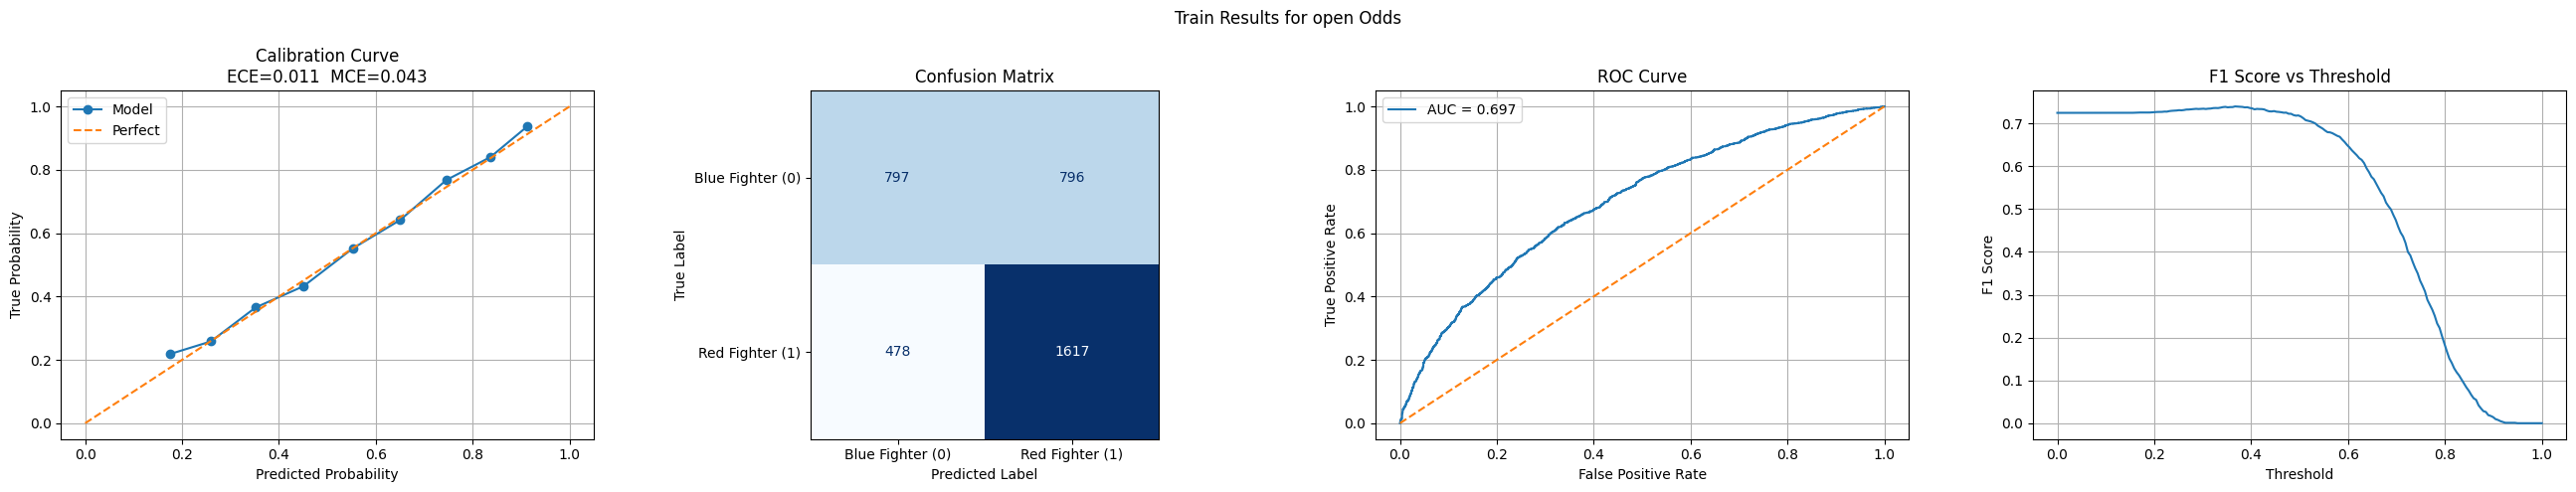

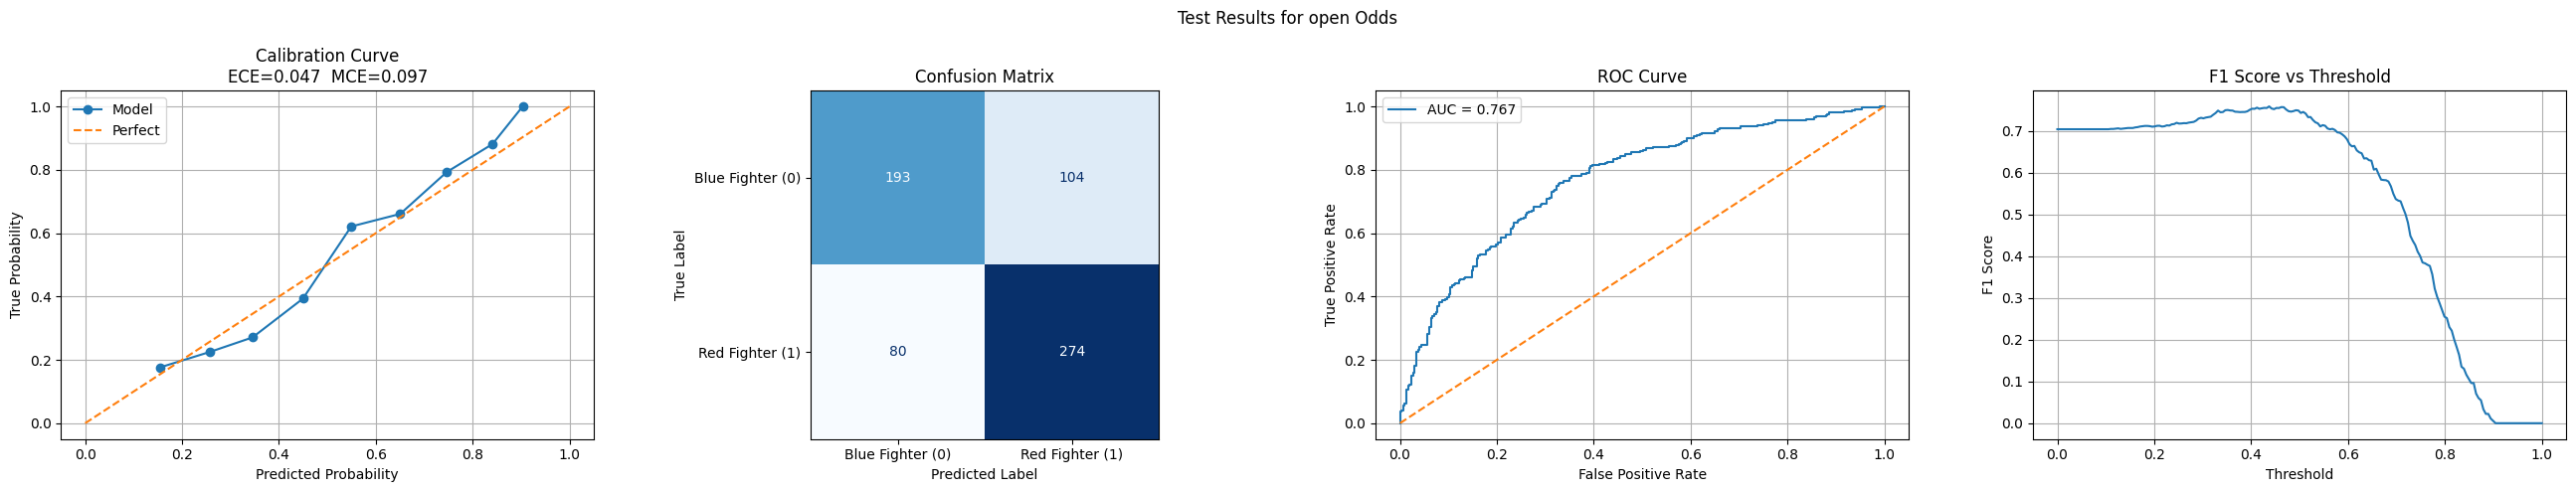

In [4]:
train_results, test_results = workflow(
    feats=config.open_feats, 
    odds_type='open',
    model_path=config.model_open_path,
    model_se_path=config.model_open_se_path,
    scalar_path=config.scaler_open_path,
    encoder_path=config.encoder_open_path,
    save_model=True,
    alpha=3.699,
)


In [5]:

def open_model_close_odds(logit, logit_se, feats_close, odds_type):

    scaler_open = joblib.load(config.scaler_open_path)
    encoder_open = joblib.load(config.encoder_open_path)

    builder = TrainTestBuilder(
        df=df_model,
        feats=feats_close,
        target_col=winner_col,
        date_col=date_col,
        odds_type=odds_type,
        year=2010, 
        month=2, 
        day=26, 
    )
    pkt = builder.prepare_train_test(
        train_size=0.85, scale=False
    )

    X_train = pkt['X_train']
    X_test = pkt['X_test']
    X_train = X_train.rename(columns={
        f'proba_fair_{odds_type}_diff': 'proba_fair_open_diff'
    })
    X_test = X_test.rename(columns={
        f'proba_fair_{odds_type}_diff': 'proba_fair_open_diff'
    })

    num_feats = [
        'proba_fair_open_diff' if f == f'proba_fair_{odds_type}_diff' else f
        for f in pkt['num_cols']
    ]
    cat_cols = pkt['cat_cols'].to_list()

    X_train[num_feats] = scaler_open.transform(X_train[num_feats])
    X_train[cat_cols] = encoder_open.transform(X_train[cat_cols])
    X_train_sm = sm.add_constant(X_train)

    X_test[num_feats] = scaler_open.transform(X_test[num_feats])
    X_test[cat_cols] = encoder_open.transform(X_test[cat_cols])
    X_test_sm = sm.add_constant(X_test)

    X_test_sm = X_test_sm[logit.model.exog_names]
    X_train_sm = X_train_sm[logit.model.exog_names]

    train_pred_proba = logit.predict(X_train_sm)
    test_pred_proba = logit.predict(X_test_sm)

    trimmed = np.asarray(logit.mle_retvals["trimmed"])
    selected = logit.params.index[~trimmed]

    proba_se_test = logit_se.get_prediction(X_test_sm[selected]).summary_frame()
    proba_se_train = logit_se.get_prediction(X_train_sm[selected]).summary_frame()

    df_train = pd.DataFrame({'proba_se':proba_se_train['se']})
    df_train = pd.concat([pkt['train_df'], df_train], axis=1)

    df_test = pd.DataFrame({'proba_se':proba_se_test['se']})
    df_test = pd.concat([pkt['test_df'], df_test], axis=1)

    df_results_train = save_results(
        df_train, 
        train_pred_proba, 
        fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open_with_{odds_type}.csv'
    )

    df_results_test = save_results(
        df_test, 
        test_pred_proba, 
        fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open_with_{odds_type}.csv'
    )



In [10]:
def test_data_open_with_close(df, feats_open, feats_open_close, odds_type, use_split=False, save_path=''):

    builder = TrainTestBuilder(
        df=df_model,
        feats=feats_open,
        target_col=winner_col,
        date_col=date_col,
        odds_type=odds_type,
        year=2010, 
        month=2, 
        day=26, 
    )
    scaler_open = joblib.load(config.scaler_open_path)
    encoder_open = joblib.load(config.encoder_open_path)

    if use_split: 
        pkt = builder.prepare_train_test(
            train_size=0.85, scale=False
        )
        X = pkt['X_test']
        df_test = pkt['test_df']
        X['proba_fair_open_diff'] = df_test['proba_fair_close1_diff']
    else: 
        X = TrainTestBuilder.close_odds_to_open(df[feats_open], df[feats_open_close], odds_type)
        X = X.dropna()
        df_test = df[builder.valid_cols].dropna()

    X['elo_pred'] = X['elo_pred'].astype('category')
    num_feats = X.select_dtypes(include='number').columns
    cat_feats = X.select_dtypes(include='category').columns

    X[num_feats] = scaler_open.transform(X[num_feats])
    encoded = pd.DataFrame(
        encoder_open.transform(X[cat_feats]),
        columns=encoder_open.get_feature_names_out(cat_feats),
        index=X.index,
    )
    X = pd.concat([X.drop(columns=cat_feats), encoded], axis=1)

    logit = sm.load(config.model_open_path)
    logit_se = sm.load(config.model_open_se_path)

    X_sm = sm.add_constant(X)
    X_sm = X_sm[logit.model.exog_names]

    proba = logit.predict(X_sm)

    trimmed = np.asarray(logit.mle_retvals["trimmed"])
    selected = logit.params.index[~trimmed]
    se = logit_se.get_prediction(X_sm[selected]).summary_frame()['se']
    df_test['proba_se'] = se

    df_results_train = save_results(
        df_test, 
        proba, 
        fp=save_path
    )
    return df_results_train

In [11]:
odds_type = 'close1'
results_close1 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-07.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close1_feats,
    odds_type = odds_type,
    use_split=True,
    save_path = fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\val_set_data_open_with_{odds_type}.csv'
)

odds_type = 'close2'
results_close2 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-07.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close2_feats,
    odds_type=odds_type,
    use_split=True,
    save_path = fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\val_set_data_open_with_{odds_type}.csv'
)

Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 51)
Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 51)


In [12]:
odds_type = 'close1'
results_close1 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close1_feats,
    odds_type = odds_type,
    use_split=False,
    save_path = fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_set_data_open_with_{odds_type}.csv'
)

odds_type = 'close2'
results_close2 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close2_feats,
    odds_type=odds_type,
    use_split=False,
    save_path = fr'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_set_data_open_with_{odds_type}.csv'
)

Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 51)
Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 51)


In [ ]:
results_close1 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close1_feats,
    odds_type='close1'
)
results_close2 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close2_feats,
    odds_type='close2'
)

In [ ]:
results_close1 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close1_feats,
    odds_type='close1'
)
results_close2 = test_data_open_with_close(
    df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\test_data\test_data.csv'),
    feats_open=config.open_feats,
    feats_open_close=config.open_close2_feats,
    odds_type='close2'
)

In [20]:
results_close1.columns

Index(['proba_fair_open_diff', 'reach_diff', 'sub_att_pm_red',
       'sub_att_pm_blue', 'ratio_control_diff', 'td_landed_pm_diff',
       'ratio_td_diff', 'adjusted_td_red', 'adjusted_td_blue',
       'sig_str_absorbed_total_diff', 'sig_str_accuracy_pct_diff',
       'sig_str_defense_pct_diff', 'adjusted_sig_str_blue',
       'adjusted_sig_str_red', 'win_pct_red', 'win_pct_blue',
       'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue',
       'elo_pred', 'age_red', 'age_blue', 'dec_fair_close1_red',
       'dec_fair_close1_blue', 'dec_close1_red', 'dec_close1_blue',
       'fighter_red', 'fighter_blue', 'winner', 'date', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'num_wins_red', 'num_wins_blue', 'num_losses_red', 'num_losses_blue',
       'dec_fair_open_red', 'dec_fair_open_blue', 'dec_fair_close1_red',
       'dec_fair_close1_blue', 'dec_fair_close2_red', 'dec_fair_close2_blue',
       'dec_open_red', 'dec_open_blue', 

In [51]:
open_model_close_odds(
    logit=sm.load(config.model_open_path),
    logit_se=sm.load(config.model_open_se_path),
    feats_close = config.open_close1_feats,
    odds_type='close1'
)
open_model_close_odds(
    logit=sm.load(config.model_open_path),
    logit_se=sm.load(config.model_open_se_path),
    feats_close = config.open_close2_feats,
    odds_type='close2'
)

Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 53)
Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 53)


Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 42)
winner
1.0    2095
0.0    1593
Name: count, dtype: int64
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.618903075627484
            Iterations: 65
            Function evaluations: 66
            Gradient evaluations: 65
                        feature       VIF
0        proba_fair_close1_diff  5.153509
1          proba_fair_open_diff  4.582069
2                 ratio_td_diff  3.572823
3             td_landed_pm_diff  3.314845
4                       elo_red  3.013793
5                      elo_blue  2.950419
6                  win_pct_blue  2.200925
7            ratio_control_diff  2.200092
8                   win_pct_red  2.071458
9     sig_str_accuracy_pct_diff  1.877938
10     sig_str_defense_pct_diff  1.797329
11             adjusted_td_blue  1.699315
12              adjusted_td_red  1.587542
13  sig_str_absorbed_total_diff  1.575708
14                      age_r

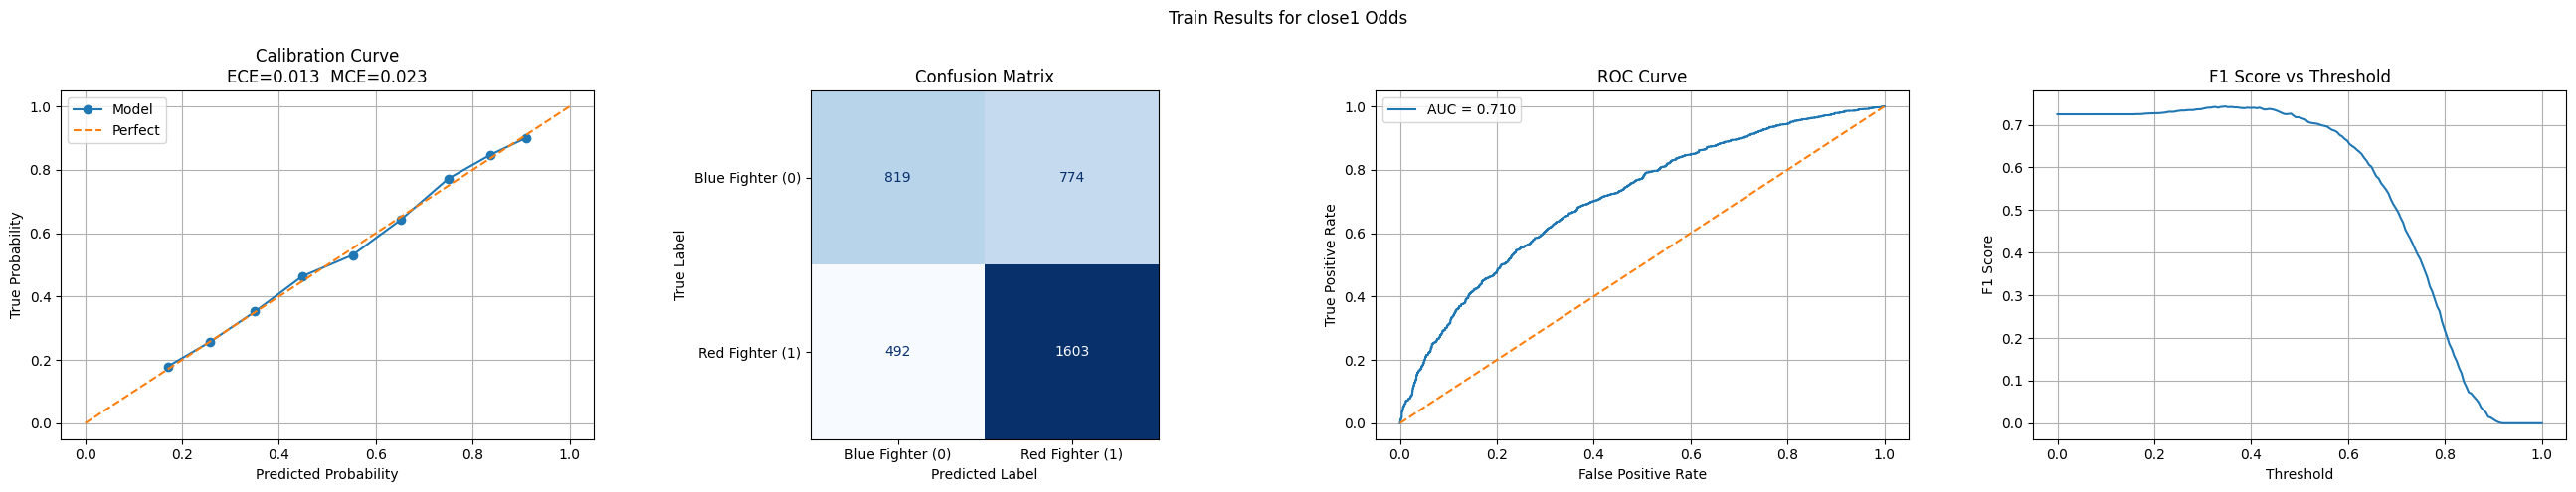

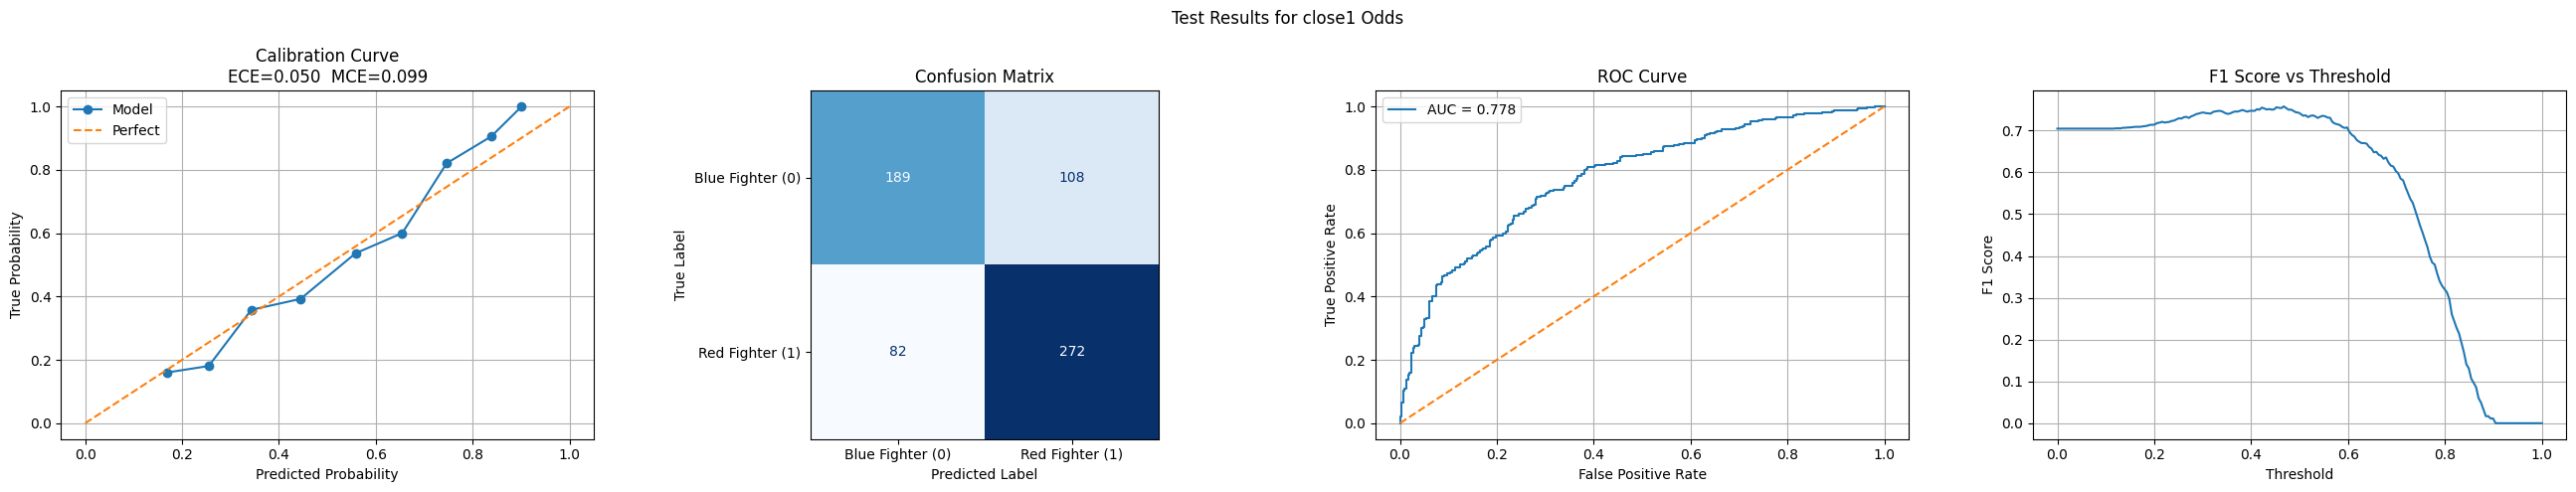

(      proba_fair_close1_diff  proba_fair_open_diff  reach_diff  \
 0                   0.414645              0.443203         1.0   
 1                  -0.201755             -0.201789         5.0   
 2                   0.589182              0.548876        -1.0   
 3                  -0.387492             -0.400036        -6.0   
 4                   0.538561              0.641499         5.0   
 ...                      ...                   ...         ...   
 3683               -0.043358             -0.291728         5.0   
 3684               -0.006350             -0.176647         0.0   
 3685               -0.409508             -0.519639        -6.0   
 3686               -0.425370             -0.348765        -1.0   
 3687               -0.611397             -0.385023         8.0   
 
       sub_att_pm_red  sub_att_pm_blue  ratio_control_diff  td_landed_pm_diff  \
 0           0.000000         0.211915           -0.248602          -0.411645   
 1           0.308344         0.

In [8]:
odds_type = 'close1'
workflow(
    feats=config.close1_feats, 
    odds_type=odds_type,
    scalar_path=fr"C:\Users\jcmar\my_files\SportsBetting\data\saved_models\scaler_{odds_type}.pkl",
    save_model=False,
    alpha=6.68,
)


Filtered: kept 4339 rows from 2010-02-26 onward.
PREPARE SHAPE: (4339, 42)
winner
1.0    2095
0.0    1593
Name: count, dtype: int64
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6177720009893861
            Iterations: 72
            Function evaluations: 73
            Gradient evaluations: 72
                        feature       VIF
0        proba_fair_close2_diff  5.209376
1          proba_fair_open_diff  4.622984
2                 ratio_td_diff  3.572020
3             td_landed_pm_diff  3.315698
4                       elo_red  3.014045
5                      elo_blue  2.950434
6                  win_pct_blue  2.201120
7            ratio_control_diff  2.199642
8                   win_pct_red  2.071549
9     sig_str_accuracy_pct_diff  1.877497
10     sig_str_defense_pct_diff  1.796358
11             adjusted_td_blue  1.698924
12              adjusted_td_red  1.587503
13  sig_str_absorbed_total_diff  1.575253
14                      age_

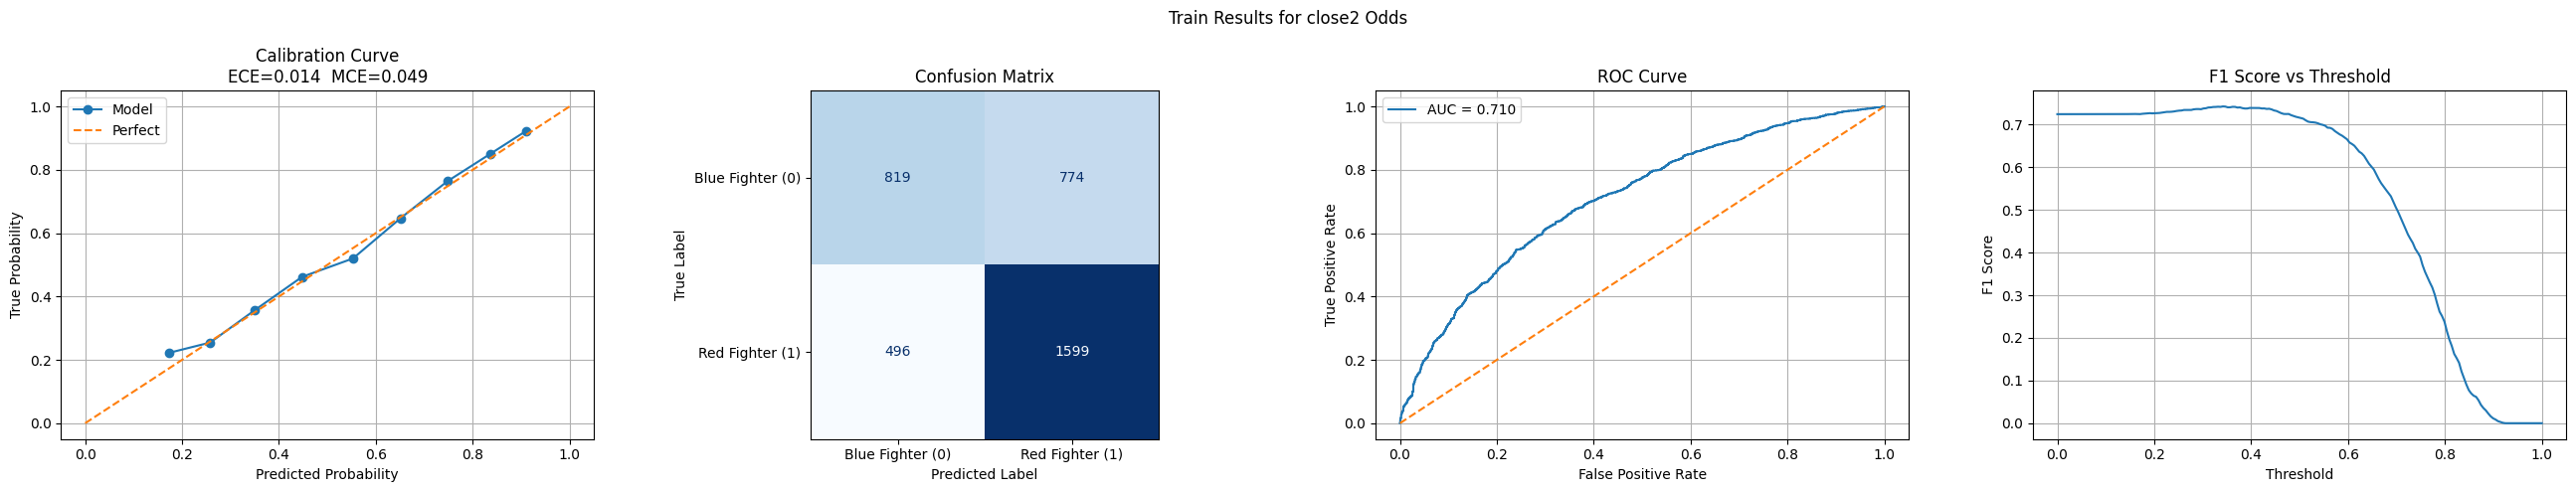

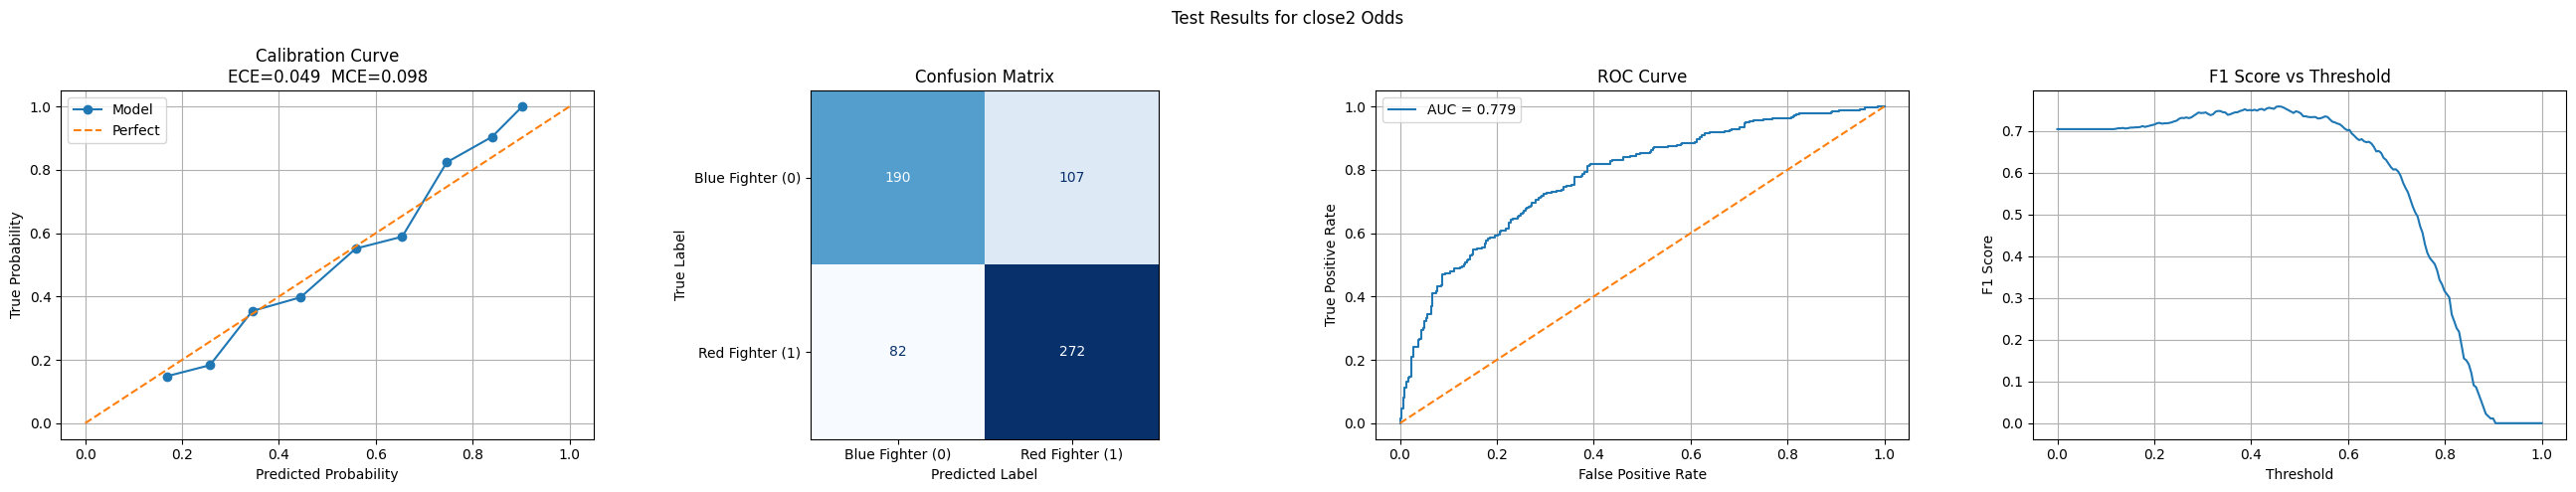

(      proba_fair_close2_diff  proba_fair_open_diff  reach_diff  \
 0                   0.414645              0.443203         1.0   
 1                  -0.201755             -0.201789         5.0   
 2                   0.589182              0.548876        -1.0   
 3                  -0.387492             -0.400036        -6.0   
 4                   0.538561              0.641499         5.0   
 ...                      ...                   ...         ...   
 3683               -0.058988             -0.291728         5.0   
 3684               -0.017091             -0.176647         0.0   
 3685               -0.393939             -0.519639        -6.0   
 3686               -0.410888             -0.348765        -1.0   
 3687               -0.590260             -0.385023         8.0   
 
       sub_att_pm_red  sub_att_pm_blue  ratio_control_diff  td_landed_pm_diff  \
 0           0.000000         0.211915           -0.248602          -0.411645   
 1           0.308344         0.

In [9]:
odds_type = 'close2'
workflow(
    feats=config.close2_feats, 
    odds_type=odds_type,
    scalar_path=fr"C:\Users\jcmar\my_files\SportsBetting\data\saved_models\scaler_{odds_type}.pkl",
    save_model=False,
    alpha=3.891,
)
